# **Author Profiling: Social Media Author Identification**

In [ ]:
%%capture
!pip install emoji

# The original files that I got are already split into training set(60%) and test set(40%). Merge all the files together and resplit them according to the 80:20 rule.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
import csv

In [ ]:
df = pd.read_csv('final_data.csv', on_bad_lines='skip', quoting=csv.QUOTE_NONE)

# filter the rows that have the right format, as in the concatenated data,
# in some rows, the labels are not 'human' or 'bot'. This causes errors while preprocessing.
df = df[(df['Truth'] == 'bot') | (df['Truth'] == 'human')]

In [ ]:
df = df.dropna()

In [ ]:
df.head()

,ID,Text,Truth,Gender
0,1004f4afed2845ffc0079096de16d6f2,No one can make you feel inferior without your...,bot,bot
1,1004f4afed2845ffc0079096de16d6f2,Read The Life and Music of Rupert Holmes http...,bot,bot
2,1004f4afed2845ffc0079096de16d6f2,Check Out Far Out and Super Cool Watches http...,bot,bot
3,1004f4afed2845ffc0079096de16d6f2,Tornado Automatic Cocktail Shaker - VERY COOL ...,bot,bot
4,1004f4afed2845ffc0079096de16d6f2,...Spinal Tap rocked my world. Its for rock wh...,bot,bot


In [ ]:
# Some example texts that have emojis
df[103:108]

,ID,Text,Truth,Gender
103,10082e6e55ae76232321207ee6038d70,@megan_hartxx Love you lots!! 💗💗,human,female
104,10082e6e55ae76232321207ee6038d70,RT @twilliamsxxx: Could honestly go on forever...,human,female
105,10082e6e55ae76232321207ee6038d70,💗💗💗💗 this https://t.co/wfGKKPCgLi,human,female
106,10082e6e55ae76232321207ee6038d70,RT @chloelittleXO: well girls it's officially ...,human,female
109,10082e6e55ae76232321207ee6038d70,RT @nicolelittlexx: MILFS😻😻😻😻😻😼😼😼😼😼 https://t....,human,female


In [ ]:
import re

def remove_emojis(text):
    """ Remove emojis in the text."""
    emoji_pattern = re.compile("["
                              u"\U0001F600-\U0001F64F"  # emoticons
                              u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                              u"\U0001F680-\U0001F6FF"  # transport & map symbols
                              u"\U0001F700-\U0001F77F"  # alchemical symbols
                              u"\U0001F780-\U0001F7FF"  # Geometric Shapes Extended
                              u"\U0001F800-\U0001F8FF"  # Supplemental Arrows-C
                              u"\U0001F900-\U0001F9FF"  # Supplemental Symbols and Pictographs
                              u"\U0001FA00-\U0001FA6F"  # Chess Symbols
                              u"\U0001FA70-\U0001FAFF"  # Symbols and Pictographs Extended-A
                              u"\U00002702-\U000027B0"  # Dingbats
                              u"\U000024C2-\U0001F251"
                              "]+", flags=re.UNICODE)
    return emoji_pattern.sub(r'', text)


In [ ]:
print(df.columns)

Index(['ID', 'Text', 'Truth', 'Gender'], dtype='object')


In [ ]:
# Apply the remove_emojis function to all texts
df['Text'] = df['Text'].apply(remove_emojis)

In [ ]:
# check whether the emojis are removed
df[103:108]

,ID,Text,Truth,Gender
103,10082e6e55ae76232321207ee6038d70,@megan_hartxx Love you lots!!,human,female
104,10082e6e55ae76232321207ee6038d70,RT @twilliamsxxx: Could honestly go on forever...,human,female
105,10082e6e55ae76232321207ee6038d70,this https://t.co/wfGKKPCgLi,human,female
106,10082e6e55ae76232321207ee6038d70,RT @chloelittleXO: well girls it's officially ...,human,female
109,10082e6e55ae76232321207ee6038d70,RT @nicolelittlexx: MILFS https://t.co/MFr9E6wwjQ,human,female


In [ ]:
# Check whether the data is balanced
truth_counts = df['Truth'].value_counts()

print("Number of human-written tweets :", truth_counts.get('human', 0))
print("Number of bot-generated tweets:", truth_counts.get('bot', 0))


Number of human-written tweets : 241664
Number of bot-generated tweets: 203230


In [ ]:
X = df['Text']
y = df['Truth']

# Split the data into 80% training set and 20% testing set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
type(X_train)

pandas.core.series.Series

In [ ]:
print('Training set shape: ', X_train.shape)
print('Training labels shape: ', y_train.shape)
print('Test set shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

Training set shape:  (355915,)
Training labels shape:  (355915,)
Test set shape:  (88979,)
Test labels shape:  (88979,)


# **Preprocessing**

## As the raw data are strings, I will implement some methods to convert strings into numbers

In [ ]:
# Count the occurencies of the words and use the counts to replace the words
from sklearn.feature_extraction.text import CountVectorizer

count_vect = CountVectorizer()
X_train_counts = count_vect.fit_transform(X_train)
X_test_counts = count_vect.transform(X_test)

In [ ]:
# Use term frequency-inverse document frequency
from sklearn.feature_extraction.text import TfidfTransformer

tfidf_tranformer = TfidfTransformer(smooth_idf=True).fit(X_train_counts)
X_train_tfidf = tfidf_tranformer.transform(X_train_counts)
X_test_tfidf = tfidf_tranformer.transform(X_test_counts)

## Next, deal with the labels. For this binary classification task, basically assign 0 and 1 to the labels 'bot' and 'human'.

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_fitted = label_encoder.fit(y_train)
y_train = label_encoder.transform(y_train)
y_test = label_encoder.transform(y_test)

# **Train the models**

## In this part, I will experiment with different classifiers/algorithms, in order to find out the best performing classifier/algorithm.

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score

In [ ]:
# Using a Naive Bayes classifier
text_clf_NB = Pipeline([
    ('vect', CountVectorizer()),
    ('tfidf', TfidfTransformer()),
    ('clf', MultinomialNB())
])

In [ ]:
text_clf_NB.fit(X_train, y_train)

Pipeline(steps=[('vect', CountVectorizer()), ('tfidf', TfidfTransformer()),
                ('clf', MultinomialNB())])

In [ ]:
scores = cross_val_score(text_clf_NB, X_train, y_train, scoring='accuracy', cv=5)
scores

In [ ]:
accuracy_score(text_clf_NB.predict(X_test),y_test)

0.8689578439856596

In [ ]:
# Using an SVM classifier
text_clf_SVC = Pipeline([
    ('vect', CountVectorizer()),
    ('tfidf', TfidfTransformer()),
    ('clf', LinearSVC())
])

In [ ]:
text_clf_SVC.fit(X_train, y_train)

Pipeline(steps=[('vect', CountVectorizer()), ('tfidf', TfidfTransformer()),
                ('clf', LinearSVC())])

In [ ]:
scores = cross_val_score(text_clf_SVC, X_train, y_train, scoring='accuracy', cv=5)
scores

array([0.89990588, 0.90124046, 0.90003231, 0.90250481, 0.9013388 ])

In [ ]:
accuracy_score(text_clf_SVC.predict(X_test),y_test)

0.9028647208891986

In [ ]:
# Using a Decision tree classifier
text_clf_RF = Pipeline([
    ('vect', CountVectorizer()),
    ('tfidf', TfidfTransformer()),
    ('clf', DecisionTreeClassifier())
])

In [ ]:
text_clf_RF.fit(X_train, y_train)

Pipeline(steps=[('vect', CountVectorizer()), ('tfidf', TfidfTransformer()),
                ('clf', DecisionTreeClassifier())])

In [ ]:
scores = cross_val_score(text_clf_RF, X_train, y_train, scoring='accuracy', cv=5)
scores

array([0.82855457, 0.82195187, 0.82640518, 0.82616636, 0.82574491])

In [ ]:
accuracy_score(text_clf_RF.predict(X_test),y_test)

0.8283078029647445

## Here I train a base model by using CountVectorizer, which takes bag-of-words as a feature, and TfidfTransformer, which takes tf-idf as a feature.  

## According to the acuracies above, we can see that the performance of the LinearSVC algorithom is the best. Since the best performing algorithm is found, we will explore additional features, combining with the best performing algorithm, in order to improve the accuracy.

## Feature 1: Character ngrams. Our hypothesis is that bots may exhibit specific characteristics in the way they generate text, such as repetitive patterns, specific combinations of characters, which can be unnatural.

## Feature 2: Word ngrams. Word ngrams capture sequential words and may help identify specific patterns or behaviors. Bots may use consistent/unatural pairs of words that differ from human behavior.

## Feature 3: Discourse connectives. Our hypothesis is that human authors often construct their tweets with greater logical coherence, potentially leading to a higher frequency of discourse connectives in their content.

## use the file 'discourse_connectives_EN_Thomas_Meyer_2014.txt' for counting the disconnective words

In [ ]:
connective_df = pd.read_csv('discourse_connectives_EN_Thomas_Meyer_2014.txt', header=None, delimiter='\t')

In [ ]:
connective_df.head()

,0,1,2
0,after,ASYNCHRONY,575/577
1,also,CONJUNCTION,1735/1746
2,although,CONTRAST,*157/328
3,as,SYNCHRONY,543/743
4,as a result,CAUSE,78/78


In [ ]:
text_df = pd.DataFrame(df, columns=["Text", "Truth"])

# Define a function to count connective words in a text
def count_connectives(text):
    return int(sum(text.lower().count(connective.lower()) for connective in connective_df[0].dropna()))


text_df["Connective_Count"] = text_df["Text"].apply(count_connectives)
text_conn_label_df = pd.DataFrame({"Text": text_df["Text"], "Connective_Count": text_df["Connective_Count"], "Truth":text_df["Truth"]})
text_conn_label_df["Connective_Count"].fillna(0, inplace=True)

In [ ]:
text_conn_label_df

,Text,Connective_Count,Truth
0,No one can make you feel inferior without your...,0,bot
1,Read The Life and Music of Rupert Holmes http...,1,bot
2,Check Out Far Out and Super Cool Watches http...,0,bot
3,Tornado Automatic Cocktail Shaker - VERY COOL ...,0,bot
4,...Spinal Tap rocked my world. Its for rock wh...,1,bot
...,...,...,...
614332,The GREAT Billy Graham an Ambassador for Chri...,1,bot
614333,A 1.6 magnitude earthquake occurred in Norther...,1,bot
614334,A 1.5 magnitude earthquake occurred in Norther...,1,bot
614335,A 1.4 magnitude earthquake occurred in Norther...,1,bot


In [ ]:
#take a look at the min and max number of connectives in the texts
text_conn_label_df["Connective_Count"].min(), text_conn_label_df["Connective_Count"].max()

(0, 16)

In [ ]:
min_connective_count_index = text_conn_label_df["Connective_Count"].idxmin()
max_connective_count_index = text_conn_label_df["Connective_Count"].idxmax()

min_connective_count_text = text_conn_label_df.loc[min_connective_count_index, "Text"]
max_connective_count_text = text_conn_label_df.loc[max_connective_count_index, "Text"]

print("Text with Minimum Connective Count:")
print(min_connective_count_text)

print("\nText with Maximum Connective Count:")
print(max_connective_count_text)


Text with Minimum Connective Count:
No one can make you feel inferior without your permission. - Eleanor Roosevelt

Text with Maximum Connective Count:
1-year-old died after stove fell on him in northeast Las Vegas - Las Vegas Review-Journal: Las Vegas Review-Journal 1-year-old died after stove fell on him in northeast Las Vegas Las Vegas Review-Journal A 1-year-old boy died last month after a stove… https://t.co/CFQbEVJ4g4 https://t.co/XZlgofXIBn


In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin
import numpy as np
from scipy.sparse import vstack, hstack


class Connective_Words(BaseEstimator, TransformerMixin):
  def __init__(self):
    self.feature_name = np.array(["connective_counts"])

  def count_connectives(self, text):
    connective_counts = int(sum(text.lower().count(connective.lower()) for connective in connective_df[0].dropna()))
    #text = [text]
    #connective_counts = sum(connective.lower() in word.lower() for word in text for connective in connective_df[0].dropna())
    #connective_counts = int(connective_counts)

    if connective_counts < 2:
      return 0
    elif connective_counts >=2 and connective_counts <=4:
     return 1
    else:
      return 2

  def fit(self, df, y=None):
    return self

  def transform(self, df, y=None):
    #print(df.shape)
    #print(np.transpose(np.matrix(df)).shape)
    num_connectives = df.map(self.count_connectives)
    return np.vstack(num_connectives.astype(float))

  def get_feature_names_out(self, input_feat):
    return self.feature_name

## Take a look at whether the selected feature 'Connective_Words' works in our model.

In [ ]:
from sklearn.pipeline import FeatureUnion

In [ ]:
features = FeatureUnion([
        ('Vect',CountVectorizer()),
        ('Connective',Connective_Words())
    ])

In [ ]:
clf4 = Pipeline([
    ('features', features),
    ('tfidf', TfidfTransformer()),
    ('clf', LinearSVC())
])

In [ ]:
clf4.fit(X_train, y_train)

Pipeline(steps=[('features',
                 FeatureUnion(transformer_list=[('Vect', CountVectorizer()),
                                                ('Connective',
                                                 Connective_Words())])),
                ('tfidf', TfidfTransformer()), ('clf', LinearSVC())])

In [ ]:
scores = cross_val_score(clf4, X_train, y_train, scoring='accuracy', cv=5)
scores

array([0.89986373, 0.90108593, 0.89999017, 0.90246267, 0.90125451])

In [ ]:
accuracy_score(clf4.predict(X_test),y_test)

0.9028534822823363

## The result is comparable(a little bit worse) with the result by using a model without the feature 'Connective_Words'.

## Accuracy without feature 'Connective_Words': array([0.89990588, 0.90124046, 0.90003231, 0.90250481, 0.9013388 ])

## Accuracy with feature 'Connective_Words': array([0.89986373, 0.90108593, 0.89999017, 0.90246267, 0.90125451])

## It's possible that bots also use a similar amount of connective words in their content, so this feature does not effectively discriminate between human and bot-generated content.

## Take a look at whether the selected features Character_Ngrams and Word_Ngrams work in the model. I think unigram does not provide useful information, so I set the ngram_range to (2,5), but I will verify this in the following steps.



In [ ]:
features_ngram = FeatureUnion([
    ('char_ngram', CountVectorizer(analyzer='char', ngram_range=(2, 5))),
    ('word_ngram', CountVectorizer(analyzer='word', ngram_range=(2, 5)))
])

In [ ]:
clf5 = Pipeline([
    ('features', features_ngram),
    ('tfidf', TfidfTransformer()),
    ('clf', LinearSVC())
])

In [ ]:
clf5.fit(X_train, y_train)

Pipeline(steps=[('features',
                 FeatureUnion(transformer_list=[('char_ngram',
                                                 CountVectorizer(analyzer='char',
                                                                 ngram_range=(2,
                                                                              5))),
                                                ('word_ngram',
                                                 CountVectorizer(ngram_range=(2,
                                                                              5)))])),
                ('tfidf', TfidfTransformer()), ('clf', LinearSVC())])

In [ ]:
scores = cross_val_score(clf5, X_train, y_train, scoring='accuracy', cv=5)
scores

array([0.93255412, 0.93136002, 0.93169717, 0.93196409, 0.93280699])

In [ ]:
accuracy_score(clf5.predict(X_test),y_test)

0.9348160801986986

## same setting, but n_gram range(1, 3)

In [ ]:
features_ngram1 = FeatureUnion([
    ('char_ngram', CountVectorizer(analyzer='char', ngram_range=(1, 3))),
    ('word_ngram', CountVectorizer(analyzer='word', ngram_range=(1, 3)))
])

In [ ]:
clf11 = Pipeline([
    ('features', features_ngram1),
    ('tfidf', TfidfTransformer()),
    ('clf', LinearSVC())
])

In [ ]:
clf11.fit(X_train, y_train)

Pipeline(steps=[('features',
                 FeatureUnion(transformer_list=[('char_ngram',
                                                 CountVectorizer(analyzer='char',
                                                                 ngram_range=(1,
                                                                              3))),
                                                ('word_ngram',
                                                 CountVectorizer(ngram_range=(1,
                                                                              3)))])),
                ('tfidf', TfidfTransformer()), ('clf', LinearSVC())])

In [ ]:
scores = cross_val_score(clf11, X_train, y_train, scoring='accuracy', cv=5)
scores

array([0.92676622, 0.92485565, 0.92682242, 0.9278058 , 0.92682242])

In [ ]:
accuracy_score(clf11.predict(X_test),y_test)

0.9295226963665584

## According to the results, the two features contribute to an accuracy improvement. And it's a little bit better than the model with the three features: Character N-grams, Word N-grams, Connective words. So I should drop the feature 'Connective words' and just use the two ngram features.

# Features: Character N-grams, Word N-grams, Connective words, ngram_range (1, 3)



In [ ]:
features_char_word_conn = Pipeline([
    ('features', FeatureUnion([
        ('CharNgrams',CountVectorizer(analyzer='char',ngram_range=(1,3))),
        ('WordNgrams',CountVectorizer(analyzer='word', ngram_range=(1,3))),
        ('Connective',Connective_Words())
    ]))
])

In [ ]:
clf6 = Pipeline([
    ('features', features_char_word_conn),
    ('tfidf', TfidfTransformer()),
    ('clf', LinearSVC())
])

In [ ]:
clf6.fit(X_train, y_train)

Pipeline(steps=[('features',
                 Pipeline(steps=[('features',
                                  FeatureUnion(transformer_list=[('CharNgrams',
                                                                  CountVectorizer(analyzer='char',
                                                                                  ngram_range=(1,
                                                                                               3))),
                                                                 ('WordNgrams',
                                                                  CountVectorizer(ngram_range=(1,
                                                                                               3))),
                                                                 ('Connective',
                                                                  Connective_Words())]))])),
                ('tfidf', TfidfTransformer()), ('clf', LinearSVC())])

In [ ]:
scores = cross_val_score(clf6, X_train, y_train, scoring='accuracy', cv=5)
scores

array([0.93041878, 0.92907014, 0.93061546, 0.93121953, 0.9306576 ])

In [ ]:
accuracy_score(clf6.predict(X_test),y_test)

0.9333550613066004

# Features: Character N-grams, Word N-grams, Connective words, ngram_range (2, 5)

In [ ]:
features_char_word_conn1 = Pipeline([
    ('features', FeatureUnion([
        ('CharNgrams',CountVectorizer(analyzer='char',ngram_range=(2,5))),
        ('WordNgrams',CountVectorizer(analyzer='word', ngram_range=(2,5))),
        ('Connective',Connective_Words())
    ]))
])

In [ ]:
clf10 = Pipeline([
    ('features', features_char_word_conn1),
    ('tfidf', TfidfTransformer()),
    ('clf', LinearSVC())
])

In [ ]:
clf10.fit(X_train, y_train)

Pipeline(steps=[('features',
                 Pipeline(steps=[('features',
                                  FeatureUnion(transformer_list=[('CharNgrams',
                                                                  CountVectorizer(analyzer='char',
                                                                                  ngram_range=(2,
                                                                                               5))),
                                                                 ('WordNgrams',
                                                                  CountVectorizer(ngram_range=(2,
                                                                                               5))),
                                                                 ('Connective',
                                                                  Connective_Words())]))])),
                ('tfidf', TfidfTransformer()), ('clf', LinearSVC())])

In [ ]:
scores = cross_val_score(clf10, X_train, y_train, scoring='accuracy', cv=5)
scores

array([0.92930896, 0.92769341, 0.9273422 , 0.92839582, 0.92912634])

In [ ]:
accuracy_score(clf10.predict(X_test),y_test)

0.9312197260027647

## Feature importance analysis

In [ ]:
!pip install eli5

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/216.2 kB ? eta -:--:--

In [ ]:
from eli5 import show_weights

In [ ]:
feat_names = features_char_word_conn1.named_steps['features'].get_feature_names_out()

In [ ]:
feat_names

array(['CharNgrams__\t', 'CharNgrams__\t1', 'CharNgrams__\t10', ...,
       'WordNgrams__ⁱˢ ᵗʰᵉ', 'WordNgrams__ⁱˢ ᵗʰᵉ ᵇʳⁱᵗ',
       'Connective__connective_counts'], dtype=object)

In [ ]:
predicted_classes = clf10.named_steps['clf'].classes_
print(predicted_classes)

[0 1]


In [ ]:
show_weights(clf10.named_steps['clf'], vec=features_char_word_conn.named_steps['features'], top=30, target_names=['bot', 'human'], targets= [0, 1], feature_names=feat_names)

Weight?,Feature
+7.996,CharNgrams__@s
+7.892,CharNgrams__@m
+7.723,CharNgrams__@a
+7.685,CharNgrams__@c
+7.450,CharNgrams__@b
+7.357,CharNgrams__@t
+7.148,CharNgrams__@d
+7.096,CharNgrams__@r
+7.037,CharNgrams__@j
+6.292,CharNgrams__@e


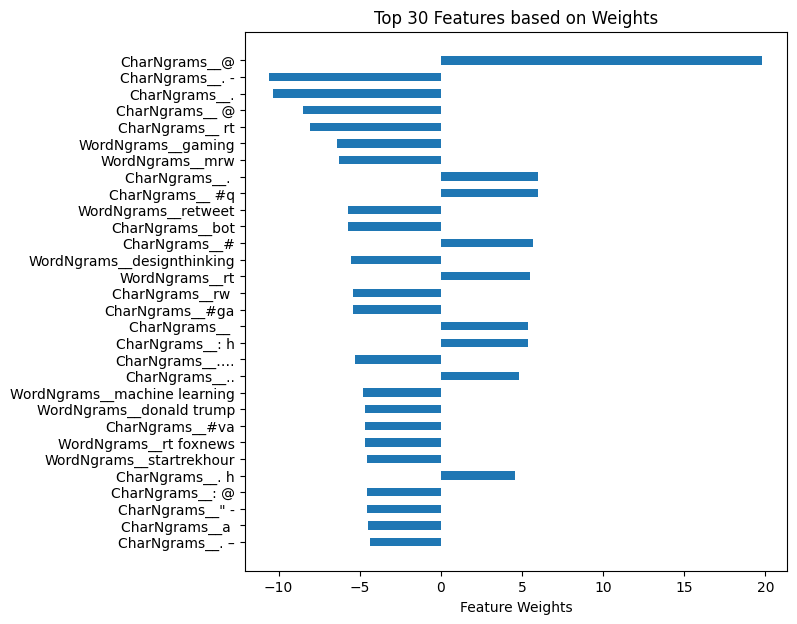

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming clf6 is a trained Logistic Regression model
coefficients = clf6.named_steps['clf'].coef_[0]
feature_names = feat_names  # Replace with your actual feature names

# Plot the top 10 features based on their weights
top_features = np.argsort(np.abs(coefficients))[-30:]
top_feature_names = [feature_names[i] for i in top_features]
top_feature_weights = coefficients[top_features]

# Adjust figure size and spacing
fig, ax = plt.subplots(figsize=(7, 7))  # Adjust the figure size as needed

# Plot the horizontal bar chart
ax.barh(top_feature_names, top_feature_weights, height=0.5)  # Adjust the height as needed

# Add labels and title
ax.set_xlabel('Feature Weights')
ax.set_title('Top 30 Features based on Weights')

# Show the plot
plt.show()



# As we can see above, the most contributive features for bots detection are CharNgrams and WordNgrams.

# Model Selection - Find the best performing hyperparameters

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'clf__C': [0.01, 0.1, 1],
    'clf__class_weight': [None, 'balanced']
}

gs_svc = GridSearchCV(clf5, param_grid, cv=2, verbose=2)
gs_svc.fit(X_train, y_train)

Fitting 2 folds for each of 6 candidates, totalling 12 fits
[CV] END ................clf__C=0.01, clf__class_weight=None; total time= 3.4min
[CV] END ................clf__C=0.01, clf__class_weight=None; total time= 3.4min
[CV] END ............clf__C=0.01, clf__class_weight=balanced; total time= 3.3min
[CV] END ............clf__C=0.01, clf__class_weight=balanced; total time= 3.3min
[CV] END .................clf__C=0.1, clf__class_weight=None; total time= 3.4min
[CV] END .................clf__C=0.1, clf__class_weight=None; total time= 3.3min
[CV] END .............clf__C=0.1, clf__class_weight=balanced; total time= 3.3min
[CV] END .............clf__C=0.1, clf__class_weight=balanced; total time= 3.2min
[CV] END ...................clf__C=1, clf__class_weight=None; total time= 3.5min
[CV] END ...................clf__C=1, clf__class_weight=None; total time= 3.5min
[CV] END ...............clf__C=1, clf__class_weight=balanced; total time= 3.6min
[CV] END ...............clf__C=1, clf__class_weig

GridSearchCV(cv=2,
             estimator=Pipeline(steps=[('features',
                                        FeatureUnion(transformer_list=[('char_ngram',
                                                                        CountVectorizer(analyzer='char',
                                                                                        ngram_range=(2,
                                                                                                     5))),
                                                                       ('word_ngram',
                                                                        CountVectorizer(ngram_range=(2,
                                                                                                     5)))])),
                                       ('tfidf', TfidfTransformer()),
                                       ('clf', LinearSVC())]),
             param_grid={'clf__C': [0.01, 0.1, 1],
                         'clf__class_weight': [None, 'balanced']},
             verbose=2)

In [ ]:
svc_df = pd.DataFrame.from_dict(gs_svc.cv_results_)
svc_df.sort_values(by=["rank_test_score"])

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_clf__C,param_clf__class_weight,params,split0_test_score,split1_test_score,mean_test_score,std_test_score,rank_test_score
5,136.668033,1.131173,77.179162,1.890529,1,balanced,"{'clf__C': 1, 'clf__class_weight': 'balanced'}",0.920723,0.921031,0.920877,0.000154,1
4,135.419677,1.946182,75.868251,1.122406,1,None,"{'clf__C': 1, 'clf__class_weight': None}",0.920509,0.920897,0.920703,0.000194,2
3,122.949192,1.792968,72.460656,0.028379,0.1,balanced,"{'clf__C': 0.1, 'clf__class_weight': 'balanced'}",0.901162,0.901341,0.901252,0.000090,3
2,125.946042,0.768624,73.782299,1.092112,0.1,None,"{'clf__C': 0.1, 'clf__class_weight': None}",0.900089,0.900948,0.900518,0.000430,4
1,124.966496,0.171202,72.433278,1.609683,0.01,balanced,"{'clf__C': 0.01, 'clf__class_weight': 'balanced'}",0.851594,0.853178,0.852386,0.000792,5
0,129.146904,1.244952,74.169941,0.355358,0.01,None,"{'clf__C': 0.01, 'clf__class_weight': None}",0.850307,0.851857,0.851082,0.000775,6


In [ ]:
from sklearn.model_selection import GridSearchCV

param = {
    'clf__C': [1, 10],
    'clf__class_weight': [None, 'balanced']
}

gs_svc = GridSearchCV(clf5, param, cv=2, verbose=2)
gs_svc.fit(X_train, y_train)

Fitting 2 folds for each of 4 candidates, totalling 8 fits
[CV] END ...................clf__C=1, clf__class_weight=None; total time= 3.6min
[CV] END ...................clf__C=1, clf__class_weight=None; total time= 3.5min
[CV] END ...............clf__C=1, clf__class_weight=balanced; total time= 3.5min
[CV] END ...............clf__C=1, clf__class_weight=balanced; total time= 3.5min
[CV] END ..................clf__C=10, clf__class_weight=None; total time= 5.3min
[CV] END ..................clf__C=10, clf__class_weight=None; total time= 5.1min
[CV] END ..............clf__C=10, clf__class_weight=balanced; total time= 5.3min
[CV] END ..............clf__C=10, clf__class_weight=balanced; total time= 5.7min


In [ ]:
svc_df = pd.DataFrame.from_dict(gs_svc.cv_results_)
svc_df.sort_values(by=["rank_test_score"])

In [ ]:
from sklearn.model_selection import GridSearchCV

param = {
    'clf__C': [1, 5],
    'clf__class_weight': [None, 'balanced']
}

gs_svc = GridSearchCV(clf5, param, cv=2, verbose=2)
gs_svc.fit(X_train, y_train)

Fitting 2 folds for each of 4 candidates, totalling 8 fits
[CV] END ...................clf__C=1, clf__class_weight=None; total time= 3.5min
[CV] END ...................clf__C=1, clf__class_weight=None; total time= 3.6min
[CV] END ...............clf__C=1, clf__class_weight=balanced; total time= 3.5min
[CV] END ...............clf__C=1, clf__class_weight=balanced; total time= 3.5min
[CV] END ...................clf__C=5, clf__class_weight=None; total time= 4.3min
[CV] END ...................clf__C=5, clf__class_weight=None; total time= 4.3min
[CV] END ...............clf__C=5, clf__class_weight=balanced; total time= 4.4min
[CV] END ...............clf__C=5, clf__class_weight=balanced; total time= 4.5min


GridSearchCV(cv=2,
             estimator=Pipeline(steps=[('features',
                                        FeatureUnion(transformer_list=[('char_ngram',
                                                                        CountVectorizer(analyzer='char',
                                                                                        ngram_range=(2,
                                                                                                     5))),
                                                                       ('word_ngram',
                                                                        CountVectorizer(ngram_range=(2,
                                                                                                     5)))])),
                                       ('tfidf', TfidfTransformer()),
                                       ('clf', LinearSVC())]),
             param_grid={'clf__C': [1, 5],
                         'clf__class_weight': [None, 'balanced']},
             verbose=2)

In [ ]:
svc_df = pd.DataFrame.from_dict(gs_svc.cv_results_)
svc_df.sort_values(by=["rank_test_score"])

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_clf__C,param_clf__class_weight,params,split0_test_score,split1_test_score,mean_test_score,std_test_score,rank_test_score
2,186.993840,0.394154,72.913719,0.073196,5,None,"{'clf__C': 5, 'clf__class_weight': None}",0.922768,0.923077,0.922923,0.000154,1
3,190.443501,1.277289,75.348256,0.628169,5,balanced,"{'clf__C': 5, 'clf__class_weight': 'balanced'}",0.922723,0.923049,0.922886,0.000163,2
1,135.599983,0.865311,75.316888,1.844201,1,balanced,"{'clf__C': 1, 'clf__class_weight': 'balanced'}",0.920723,0.921031,0.920877,0.000154,3
0,137.213818,2.303670,74.986807,1.474435,1,None,"{'clf__C': 1, 'clf__class_weight': None}",0.920509,0.920897,0.920703,0.000194,4


## Experiment with the ngram_range to find out whether smaller N or lager N is better for the model.

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'features__char_ngram__ngram_range':[(1,3),(3,5)],
    'features__word_ngram__ngram_range':[(1,3),(3,5)]
}

gs_svc = GridSearchCV(clf5, param_grid, cv=2, verbose=2)
gs_svc.fit(X_train, y_train)

Fitting 2 folds for each of 4 candidates, totalling 8 fits
[CV] END features__char_ngram__ngram_range=(1, 3), features__word_ngram__ngram_range=(1, 3); total time= 1.7min
[CV] END features__char_ngram__ngram_range=(1, 3), features__word_ngram__ngram_range=(1, 3); total time= 1.7min
[CV] END features__char_ngram__ngram_range=(1, 3), features__word_ngram__ngram_range=(3, 5); total time= 1.8min
[CV] END features__char_ngram__ngram_range=(1, 3), features__word_ngram__ngram_range=(3, 5); total time= 1.7min
[CV] END features__char_ngram__ngram_range=(3, 5), features__word_ngram__ngram_range=(1, 3); total time= 2.7min
[CV] END features__char_ngram__ngram_range=(3, 5), features__word_ngram__ngram_range=(1, 3); total time= 2.8min
[CV] END features__char_ngram__ngram_range=(3, 5), features__word_ngram__ngram_range=(3, 5); total time= 2.8min
[CV] END features__char_ngram__ngram_range=(3, 5), features__word_ngram__ngram_range=(3, 5); total time= 2.9min


GridSearchCV(cv=2,
             estimator=Pipeline(steps=[('features',
                                        FeatureUnion(transformer_list=[('char_ngram',
                                                                        CountVectorizer(analyzer='char',
                                                                                        ngram_range=(2,
                                                                                                     5))),
                                                                       ('word_ngram',
                                                                        CountVectorizer(ngram_range=(2,
                                                                                                     5)))])),
                                       ('tfidf', TfidfTransformer()),
                                       ('clf', LinearSVC())]),
             param_grid={'features__char_ngram__ngram_range': [(1, 3), (3, 5)],
                         'features__word_ngram__ngram_range': [(1, 3), (3, 5)]},
             verbose=2)

In [ ]:
svc_df = pd.DataFrame.from_dict(gs_svc.cv_results_)
svc_df.sort_values(by=["rank_test_score"])

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_features__char_ngram__ngram_range,param_features__word_ngram__ngram_range,params,split0_test_score,split1_test_score,mean_test_score,std_test_score,rank_test_score
0,61.824690,0.722705,39.460479,1.161683,"(1, 3)","(1, 3)","{'features__char_ngram__ngram_range': (1, 3), ...",0.923454,0.923622,0.923538,0.000084,1
2,105.889963,2.026729,58.042464,0.669893,"(3, 5)","(1, 3)","{'features__char_ngram__ngram_range': (3, 5), ...",0.922173,0.922206,0.922189,0.000017,2
3,113.125856,1.639293,57.265162,0.319503,"(3, 5)","(3, 5)","{'features__char_ngram__ngram_range': (3, 5), ...",0.920521,0.920571,0.920546,0.000025,3
1,70.067341,0.799189,35.735892,0.929406,"(1, 3)","(3, 5)","{'features__char_ngram__ngram_range': (1, 3), ...",0.913041,0.913198,0.913120,0.000078,4


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'features__CharNgrams__ngram_range':[(1,3),(3,5)],
    'features__WordNgrams__ngram_range':[(1,3),(3,5)]
}

gs_svc = GridSearchCV(clf6, param_grid, cv=2, verbose=2)
gs_svc.fit(X_train, y_train)

Fitting 2 folds for each of 4 candidates, totalling 8 fits
[CV] END features__CharNgrams__ngram_range=(1, 3), features__WordNgrams__ngram_range=(1, 3); total time= 2.2min
[CV] END features__CharNgrams__ngram_range=(1, 3), features__WordNgrams__ngram_range=(1, 3); total time= 2.3min
[CV] END features__CharNgrams__ngram_range=(1, 3), features__WordNgrams__ngram_range=(3, 5); total time= 2.4min
[CV] END features__CharNgrams__ngram_range=(1, 3), features__WordNgrams__ngram_range=(3, 5); total time= 2.5min
[CV] END features__CharNgrams__ngram_range=(3, 5), features__WordNgrams__ngram_range=(1, 3); total time= 3.5min
[CV] END features__CharNgrams__ngram_range=(3, 5), features__WordNgrams__ngram_range=(1, 3); total time= 3.3min
[CV] END features__CharNgrams__ngram_range=(3, 5), features__WordNgrams__ngram_range=(3, 5); total time= 3.4min
[CV] END features__CharNgrams__ngram_range=(3, 5), features__WordNgrams__ngram_range=(3, 5); total time= 3.4min


GridSearchCV(cv=2,
             estimator=Pipeline(steps=[('features',
                                        FeatureUnion(transformer_list=[('CharNgrams',
                                                                        CountVectorizer(analyzer='char',
                                                                                        ngram_range=(1,
                                                                                                     3))),
                                                                       ('WordNgrams',
                                                                        CountVectorizer(ngram_range=(1,
                                                                                                     3))),
                                                                       ('Connective',
                                                                        Connective_Words())])),
                                       ('tfidf', TfidfTransformer()),
                                       ('clf', LinearSVC())]),
             param_grid={'features__CharNgrams__ngram_range': [(1, 3), (3, 5)],
                         'features__WordNgrams__ngram_range': [(1, 3), (3, 5)]},
             verbose=2)

In [ ]:
svc_df = pd.DataFrame.from_dict(gs_svc.cv_results_)
svc_df.sort_values(by=["rank_test_score"])

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_features__CharNgrams__ngram_range,param_features__WordNgrams__ngram_range,params,split0_test_score,split1_test_score,mean_test_score,std_test_score,rank_test_score
0,80.342333,1.393130,55.115159,0.459450,"(1, 3)","(1, 3)","{'features__CharNgrams__ngram_range': (1, 3), ...",0.923454,0.923644,0.923549,0.000095,1
2,126.997213,3.653247,79.497245,2.752359,"(3, 5)","(1, 3)","{'features__CharNgrams__ngram_range': (3, 5), ...",0.922184,0.922217,0.922201,0.000017,2
3,128.445417,1.896954,75.954091,0.836589,"(3, 5)","(3, 5)","{'features__CharNgrams__ngram_range': (3, 5), ...",0.920521,0.920694,0.920607,0.000087,3
1,91.302323,1.791869,56.579095,1.887403,"(1, 3)","(3, 5)","{'features__CharNgrams__ngram_range': (1, 3), ...",0.912968,0.913221,0.913094,0.000126,4


## The ngram_range parameters that GridSearchCV suggest are just same as the parameters that I used. And the accuracy result is camparable to the best performing result of the sahred-task.

In [ ]:
features_ngram = FeatureUnion([
    ('char_ngram', CountVectorizer(analyzer='char', ngram_range=(1, 3))),
    ('word_ngram', CountVectorizer(analyzer='word', ngram_range=(1, 3)))
])

In [ ]:
clf8 = Pipeline([
    ('features', features_ngram),
    ('tfidf', TfidfTransformer()),
    ('clf', LinearSVC())
])

In [ ]:
clf8.fit(X_train, y_train)

Pipeline(steps=[('features',
                 FeatureUnion(transformer_list=[('char_ngram',
                                                 CountVectorizer(analyzer='char',
                                                                 ngram_range=(1,
                                                                              3))),
                                                ('word_ngram',
                                                 CountVectorizer(ngram_range=(1,
                                                                              3)))])),
                ('tfidf', TfidfTransformer()), ('clf', LinearSVC())])

In [ ]:
scores = cross_val_score(clf8, X_train, y_train, scoring='accuracy', cv=5)
scores

array([0.93043283, 0.92908419, 0.9306576 , 0.93126168, 0.93078404])

In [ ]:
accuracy_score(clf8.predict(X_test),y_test)

0.9334112543409119

## There seems overfitting in our model, as the performance of the model on the test set is slightly better than on the training set. Maybe it is related to the data split, now we will experiment with the original data split (60:40)

In [ ]:
X = df['Text']
y = df['Truth']

# Split the data into 60% training set and 40% testing set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

In [ ]:
print('Training set shape: ', X_train.shape)
print('Training labels shape: ', y_train.shape)
print('Test set shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

Training set shape:  (266936,)
Training labels shape:  (266936,)
Test set shape:  (177958,)
Test labels shape:  (177958,)


In [ ]:
# Count the occurencies of the words and use the counts to replace the words
from sklearn.feature_extraction.text import CountVectorizer

count_vect = CountVectorizer()
X_train_counts = count_vect.fit_transform(X_train)
X_test_counts = count_vect.transform(X_test)

In [ ]:
# Use term frequency-inverse document frequency
from sklearn.feature_extraction.text import TfidfTransformer

tfidf_tranformer = TfidfTransformer(smooth_idf=True).fit(X_train_counts)
X_train_tfidf = tfidf_tranformer.transform(X_train_counts)
X_test_tfidf = tfidf_tranformer.transform(X_test_counts)

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

In [ ]:
from sklearn.pipeline import FeatureUnion

features_ngram = FeatureUnion([
    ('char_ngram', CountVectorizer(analyzer='char', ngram_range=(2, 5))),
    ('word_ngram', CountVectorizer(analyzer='word', ngram_range=(2, 5)))
])

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline


clf7 = Pipeline([
    ('features', features_ngram),
    ('tfidf', TfidfTransformer()),
    ('clf', LinearSVC())
])

In [ ]:
clf7.fit(X_train, y_train)

Pipeline(steps=[('features',
                 FeatureUnion(transformer_list=[('char_ngram',
                                                 CountVectorizer(analyzer='char',
                                                                 ngram_range=(2,
                                                                              5))),
                                                ('word_ngram',
                                                 CountVectorizer(ngram_range=(2,
                                                                              5)))])),
                ('tfidf', TfidfTransformer()), ('clf', LinearSVC())])

In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(clf7, X_train, y_train, scoring='accuracy', cv=5)
scores

array([0.92590095, 0.92840954, 0.92668627, 0.92795999, 0.92677993])

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(clf7.predict(X_test),y_test)

0.9310904820238484